In [1]:
import pandas as pd
import numpy as np
import pickle, os, warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── paths (ปรับตาม project structure) ─────────────────────────────
RECIPES_PATH = "../resources/cleaned_ready_for_es.pkl"
REVIEWS_PATH = "../resources/reviews.csv"
OUT_DIR      = "model_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

# ── hyperparams ────────────────────────────────────────────────────
SVD_COMPONENTS  = 100   # จำนวน SVD components
TFIDF_MAX_FEAT  = 30_000
OPTUNA_TRIALS   = 50
RANDOM_STATE    = 42

print("✅ Imports done")

✅ Imports done


In [4]:
recipes = pd.read_pickle(RECIPES_PATH)
reviews = pd.read_csv(REVIEWS_PATH)

print(f"Recipes  shape : {recipes.shape}")
print(f"Reviews  shape : {reviews.shape}")
print()
print("Recipes columns :", recipes.columns.tolist())
print("Reviews columns :", reviews.columns.tolist())

Recipes  shape : (520297, 16)
Reviews  shape : (1401982, 8)

Recipes columns : ['RecipeId', 'Name', 'TotalTime', 'Description', 'Images', 'RecipeCategory', 'Keywords', 'RecipeIngredientQuantities', 'RecipeIngredientParts', 'AggregatedRating', 'ReviewCount', 'RecipeYield', 'RecipeInstructions', 'Name_clean', 'RecipeIngredientParts_clean', 'RecipeInstructions_clean']
Reviews columns : ['ReviewId', 'RecipeId', 'AuthorId', 'AuthorName', 'Rating', 'Review', 'DateSubmitted', 'DateModified']


In [5]:
# preview
display(recipes.head(3))
display(reviews.head(3))

,RecipeId,Name,TotalTime,Description,Images,RecipeCategory,Keywords,RecipeIngredientQuantities,RecipeIngredientParts,AggregatedRating,ReviewCount,RecipeYield,RecipeInstructions,Name_clean,RecipeIngredientParts_clean,RecipeInstructions_clean
0,38,Low-Fat Berry Blue Frozen Dessert,PT24H45M,Make and share this Low-Fat Berry Blue Frozen ...,https://img.sndimg.com/food/image/upload/w_555...,Frozen Desserts,"c(""Dessert"", ""Low Protein"", ""Low Cholesterol"",...","c(""4"", ""1/4"", ""1"", ""1"")",blueberries granulated sugar vanilla yogurt le...,4.5,4.0,<NA>,Toss 2 cups berries with sugar. Let stand for ...,low fat berry blue frozen dessert,blueberries granulated sugar vanilla yogurt le...,toss 2 cups berries with sugar let stand for 4...
1,39,Biryani,PT4H25M,Make and share this Biryani recipe from Food.com.,https://img.sndimg.com/food/image/upload/w_555...,Chicken Breast,"c(""Chicken Thigh & Leg"", ""Chicken"", ""Poultry"",...","c(""1"", ""4"", ""2"", ""2"", ""8"", ""1/4"", ""8"", ""1/2"", ...",saffron milk hot green chili peppers onions ga...,3.0,1.0,<NA>,Soak saffron in warm milk for 5 minutes and pu...,biryani,saffron milk hot green chili peppers onions ga...,soak saffron in warm milk for 5 minutes and pu...
2,40,Best Lemonade,PT35M,This is from one of my first Good House Keepi...,https://img.sndimg.com/food/image/upload/w_555...,Beverages,"c(""Low Protein"", ""Low Cholesterol"", ""Healthy"",...","c(""1 1/2"", ""1"", NA, ""1 1/2"", NA, ""3/4"")","sugar lemons, rind of lemon, zest of fresh wat...",4.5,10.0,<NA>,"Into a 1 quart Jar with tight fitting lid, put...",best lemonade,sugar lemons rind of lemon zest of fresh water...,into a 1 quart jar with tight fitting lid put ...


,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25T21:44:00Z,2000-01-25T21:44:00Z
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25T09:00:00Z,2000-02-25T09:00:00Z


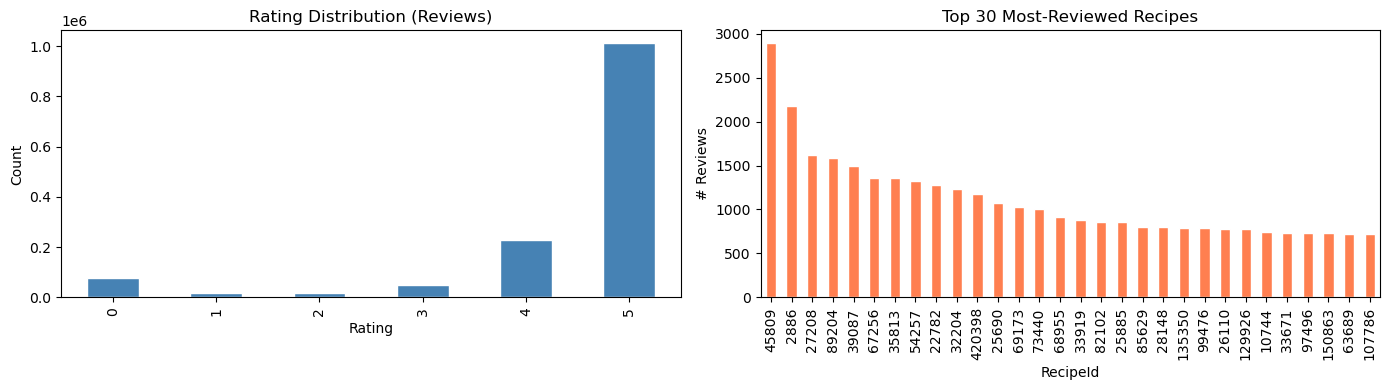


Rating stats:
count    1.401982e+06
mean     4.407951e+00
std      1.272012e+00
min      0.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating distribution
reviews["Rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Rating Distribution (Reviews)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Reviews per recipe (top 30)
top_recipes = reviews.groupby("RecipeId").size().sort_values(ascending=False).head(30)
top_recipes.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Top 30 Most-Reviewed Recipes")
axes[1].set_xlabel("RecipeId")
axes[1].set_ylabel("# Reviews")

plt.tight_layout()
plt.show()

print(f"\nRating stats:")
print(reviews["Rating"].describe())

In [8]:
# ใช้ search_text เป็น main text column
# ถ้าไม่มีให้ fallback ไปที่ processed_text หรือ description
TEXT_COL = "search_text"
if TEXT_COL not in recipes.columns:
    TEXT_COL = "processed_text" if "processed_text" in recipes.columns else "Description"
    print(f"⚠️  'search_text' not found — using '{TEXT_COL}'")

texts = recipes[TEXT_COL].fillna("").astype(str)

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEAT,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
tfidf_matrix = tfidf.fit_transform(texts)

print(f"✅ TF-IDF shape : {tfidf_matrix.shape}")
print(f"   Vocabulary   : {len(tfidf.vocabulary_):,} terms")

⚠️  'search_text' not found — using 'Description'
✅ TF-IDF shape : (520297, 30000)
   Vocabulary   : 30,000 terms


✅ SVD shape        : (520297, 100)
   Explained var   : 0.153 (15.3%)


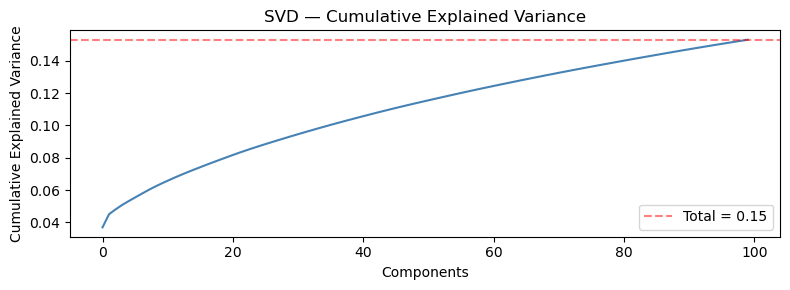

In [9]:
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
svd_features = svd.fit_transform(tfidf_matrix)

explained = svd.explained_variance_ratio_.sum()
print(f"✅ SVD shape        : {svd_features.shape}")
print(f"   Explained var   : {explained:.3f} ({explained*100:.1f}%)")

# plot cumulative explained variance
plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(svd.explained_variance_ratio_), color="steelblue")
plt.axhline(y=explained, color="red", linestyle="--", alpha=0.5, label=f"Total = {explained:.2f}")
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("SVD — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── map recipe_id -> svd row index ──────────────────────────────
recipe_id_to_idx = {rid: i for i, rid in enumerate(recipes["RecipeId"])}

reviews_with_bk = reviews.copy()   # ใช้ reviews ทั้งหมดเป็น proxy

# ── clean ────────────────────────────────────────────────────────
reviews_clean = reviews_with_bk.dropna(subset=["Rating"]).copy()
reviews_clean["Rating"] = reviews_clean["Rating"].astype(float)

# กรองเฉพาะ recipe ที่มี features
valid_mask = reviews_clean["RecipeId"].isin(recipe_id_to_idx)
reviews_clean = reviews_clean[valid_mask].copy()
print(f"Usable rows after filter : {len(reviews_clean):,}")

Usable rows after filter : 1,396,477


In [11]:
# ── user-level features ─────────────────────────────────────────
user_stats = (
    reviews_clean.groupby("AuthorId")["Rating"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "user_avg_rating",
                     "std":  "user_std_rating",
                     "count":"user_review_count"})
    .fillna(0)
    .reset_index()
)

# ── recipe-level features ────────────────────────────────────────
recipe_stats = (
    reviews_clean.groupby("RecipeId")["Rating"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "recipe_avg_rating",
                     "std":  "recipe_std_rating",
                     "count":"recipe_review_count"})
    .fillna(0)
    .reset_index()
)

df = reviews_clean[["AuthorId", "RecipeId", "Rating"]].copy()
df = df.merge(user_stats,   on="AuthorId",  how="left")
df = df.merge(recipe_stats, on="RecipeId",  how="left")

# ── attach SVD features ──────────────────────────────────────────
svd_cols  = [f"svd_{i}" for i in range(SVD_COMPONENTS)]
svd_idx   = df["RecipeId"].map(recipe_id_to_idx).values
svd_df    = pd.DataFrame(svd_features[svd_idx], columns=svd_cols)

base_cols = ["user_avg_rating", "user_std_rating", "user_review_count",
             "recipe_avg_rating", "recipe_std_rating", "recipe_review_count"]

X = pd.concat([df[base_cols].reset_index(drop=True),
               svd_df.reset_index(drop=True)], axis=1)
y = df["Rating"].reset_index(drop=True)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
display(X[base_cols].describe())

X shape : (1396477, 106)
y shape : (1396477,)


,user_avg_rating,user_std_rating,user_review_count,recipe_avg_rating,recipe_std_rating,recipe_review_count
count,1.396477e+06,1.396477e+06,1.396477e+06,1.396477e+06,1.396477e+06,1.396477e+06
mean,4.407810e+00,6.995154e-01,5.573190e+02,4.407810e+00,9.382080e-01,8.051357e+01
std,9.393418e-01,5.760533e-01,1.174627e+03,6.290328e-01,7.141551e-01,2.368083e+02
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,4.354478e+00,3.164597e-01,6.000000e+00,4.222854e+00,3.779645e-01,4.000000e+00
50%,4.676580e+00,6.555823e-01,7.400000e+01,4.521739e+00,9.566835e-01,1.200000e+01
75%,4.880810e+00,9.759001e-01,5.170000e+02,4.800000e+00,1.414214e+00,4.900000e+01
max,5.000000e+00,3.535534e+00,8.822000e+03,5.000000e+00,3.535534e+00,2.892000e+03


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}")
print(f"Train ratings mean : {y_train.mean():.2f}")
print(f"Val   ratings mean : {y_val.mean():.2f}")

Train : (1117181, 106)  |  Val : (279296, 106)
Train ratings mean : 4.41
Val   ratings mean : 4.41


In [13]:
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain, free_raw_data=False)

def objective(trial):
    params = {
        "objective":          "regression",
        "metric":             "rmse",
        "verbosity":          -1,
        "boosting_type":      "gbdt",
        "n_jobs":             -1,
        "seed":               RANDOM_STATE,
        "feature_pre_filter": False,          # ← แก้ error นี้
        # ── tunable params ─────────────────────────────────────
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    # สร้าง dataset ใหม่ทุก trial ป้องกัน cached params conflict
    _dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
    _dval   = lgb.Dataset(X_val,   label=y_val, reference=_dtrain, free_raw_data=False)

    callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    model = lgb.train(params, _dtrain, valid_sets=[_dval], callbacks=callbacks)
    return model.best_score["valid_0"]["rmse"]

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f"\n✅ Best Val RMSE : {study.best_value:.4f}")
print(f"   Best params  :\n", best_params)

Best trial: 21. Best value: 0.732183: 100%|██████████| 50/50 [34:55<00:00, 41.92s/it]


✅ Best Val RMSE : 0.7322
   Best params  :
 {'num_leaves': 293, 'max_depth': 9, 'learning_rate': 0.006130481880097339, 'n_estimators': 931, 'min_child_samples': 63, 'subsample': 0.9417898756164378, 'colsample_bytree': 0.8559940924607298, 'reg_alpha': 0.002113019527063467, 'reg_lambda': 8.27101575884589}


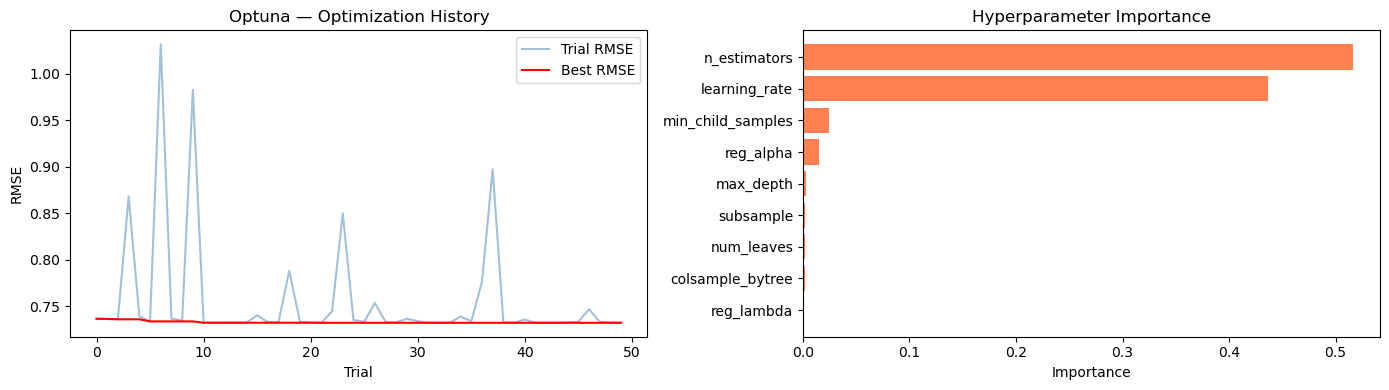

In [14]:
# ── Plot Optuna optimization history ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df["value"], color="steelblue", alpha=0.5, label="Trial RMSE")
axes[0].plot(trials_df["value"].cummin(), color="red", label="Best RMSE")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Optuna — Optimization History")
axes[0].legend()

# Param importance
try:
    importances = optuna.importance.get_param_importances(study)
    params_imp  = list(importances.keys())
    values_imp  = list(importances.values())
    axes[1].barh(params_imp[::-1], values_imp[::-1], color="coral")
    axes[1].set_title("Hyperparameter Importance")
    axes[1].set_xlabel("Importance")
except Exception as e:
    axes[1].text(0.5, 0.5, f"Importance not available\n{e}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [15]:
final_params = {
    "objective":     "regression",
    "metric":        "rmse",
    "verbosity":     -1,
    "boosting_type": "gbdt",
    "n_jobs":        -1,
    "seed":          RANDOM_STATE,
    **best_params,
}

callbacks = [
    lgb.early_stopping(100, verbose=True),
    lgb.log_evaluation(50),
]

model = lgb.train(
    final_params,
    dtrain,
    num_boost_round=best_params.get("n_estimators", 500),
    valid_sets=[dval],
    callbacks=callbacks,
)

val_rmse = model.best_score["valid_0"]["rmse"]
print(f"\n🎯 Final Val RMSE : {val_rmse:.4f}")

Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 1.07503
[100]	valid_0's rmse: 0.94319
[150]	valid_0's rmse: 0.861368
[200]	valid_0's rmse: 0.810353
[250]	valid_0's rmse: 0.781447
[300]	valid_0's rmse: 0.76178
[350]	valid_0's rmse: 0.749594
[400]	valid_0's rmse: 0.743101
[450]	valid_0's rmse: 0.738787
[500]	valid_0's rmse: 0.736179
[550]	valid_0's rmse: 0.734588
[600]	valid_0's rmse: 0.733618
[650]	valid_0's rmse: 0.73303
[700]	valid_0's rmse: 0.73264
[750]	valid_0's rmse: 0.732395
[800]	valid_0's rmse: 0.732246
[850]	valid_0's rmse: 0.732195
[900]	valid_0's rmse: 0.732194
Did not meet early stopping. Best iteration is:
[874]	valid_0's rmse: 0.732183

🎯 Final Val RMSE : 0.7322


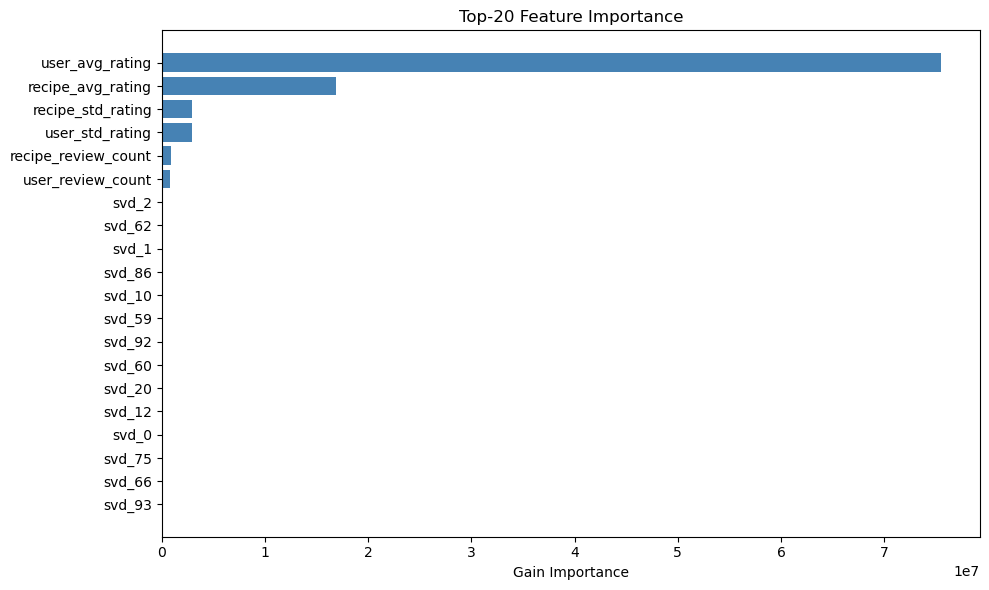


Top-10 features:


,feature,importance
0,user_avg_rating,7.549479e+07
3,recipe_avg_rating,1.687633e+07
4,recipe_std_rating,2.937491e+06
1,user_std_rating,2.912259e+06
5,recipe_review_count,8.515741e+05
2,user_review_count,8.332635e+05
8,svd_2,2.278266e+04
68,svd_62,2.269490e+04
7,svd_1,2.053946e+04
92,svd_86,2.047607e+04


In [16]:
# ── Feature Importance ────────────────────────────────────────────
feat_imp = pd.DataFrame({
    "feature":    model.feature_name(),
    "importance": model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False)

# top-20 (แสดง base features + top SVD)
top20 = feat_imp.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
plt.xlabel("Gain Importance")
plt.title("Top-20 Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop-10 features:")
display(feat_imp.head(10))

In [17]:
with open(f"{OUT_DIR}/tfidf.pkl",            "wb") as f: pickle.dump(tfidf, f)
with open(f"{OUT_DIR}/svd.pkl",              "wb") as f: pickle.dump(svd, f)
with open(f"{OUT_DIR}/recipe_id_to_idx.pkl", "wb") as f: pickle.dump(recipe_id_to_idx, f)
model.save_model(f"{OUT_DIR}/lgbm_model.txt")

print(f"💾 Saved to '{OUT_DIR}/':")
for f in os.listdir(OUT_DIR):
    size = os.path.getsize(f"{OUT_DIR}/{f}")
    print(f"   {f}  ({size/1024:.1f} KB)")

💾 Saved to 'model_artifacts/':
   tfidf.pkl  (30152.0 KB)
   lgbm_model.txt  (19517.7 KB)
   recipe_id_to_idx.pkl  (4835.3 KB)
   svd.pkl  (23440.4 KB)
